# Global Stuffs

In [2]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import h5py
import re

## functions

In [3]:
def set_plot_style(axs, fonts, xlabel, ylabel):
    axs.set_xlabel(xlabel, fontsize=fonts)
    axs.set_ylabel(ylabel, fontsize=fonts)
    axs.tick_params(axis='both', which='major', direction='out', length=4, width=1)
    axs.tick_params(which='minor', width=1, size=2)  # Adjust size as needed
    axs.minorticks_on() # Turn on minor ticks
    
    #axs.grid(False, which='both', axis='both', linestyle='--', linewidth=0.5)
    axs.set_facecolor('white')
    axs.spines['top'].set_linewidth(1)
    axs.spines['right'].set_linewidth(1)
    axs.spines['bottom'].set_linewidth(1)
    axs.spines['left'].set_linewidth(1)
    axs.tick_params(axis='x', labelsize=fonts)
    axs.tick_params(axis='y', labelsize=fonts)

    return axs

def darken_colors(num_colors, darker_factor=0.7):
    colors = plt.cm.jet(np.linspace(0, 1, num_colors))
    darker_colors = colors.copy()

    for i in range(num_colors):
        rgb = darker_colors[i, :3]
        hsv = plt.cm.colors.rgb_to_hsv(rgb)
        hsv[2] *= darker_factor
        darker_colors[i, :3] = plt.cm.colors.hsv_to_rgb(hsv)

    return darker_colors


def create_label(filename):
    # Only modify if any target patterns exist
    if any(x in filename for x in ['thresh1_', 'f_', 'azimuthal', 'P3HB', 'rep_', '_01', 'subtracted_avg_']):
        label = filename.split('.')[0]
        label = label.replace('thresh1_', '').split('_Scan')[0]
        label = label.split('f_')[-1] if 'f_' in label else label
        label = label.split('_azimuthal')[0] if 'azimuthal' in label else label
        label = label.replace('P3HB', 'PHA-3B')
        label = label.replace('rep_', '').replace('_01', '')
        label = label.replace('subtracted_avg_', '')
    else:
        label = filename.split('.')[0]  # just remove extension, no other changes
    return label


## read and plot excel files

## linkam tensile function

Property: Stress
Start time: 2025-05-24 13:04:48.199520
                      time   Stress
2025-05-24 13:04:48.199520 -2.28471
2025-05-24 13:04:48.458380 -2.28507
2025-05-24 13:04:48.717230 -2.28544
2025-05-24 13:04:48.976080 -2.28532
2025-05-24 13:04:49.234930 -2.28525


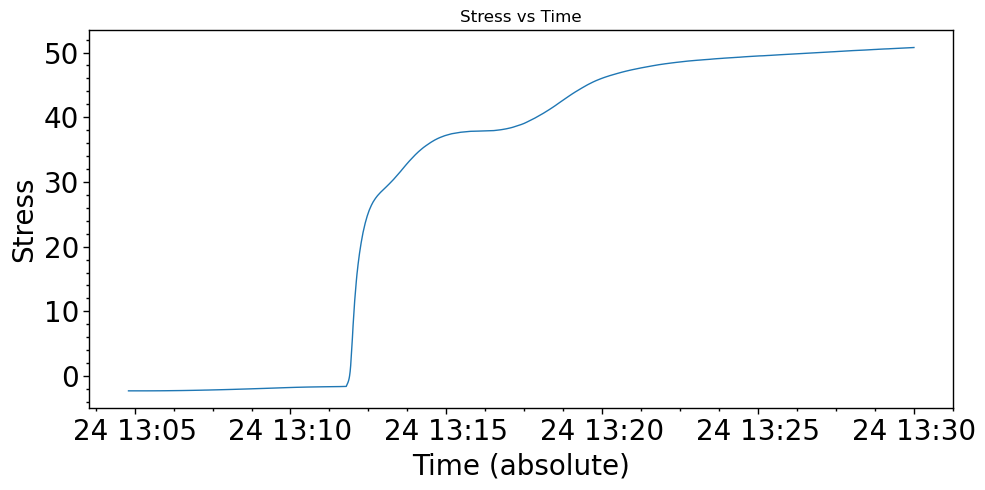

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def load_linkam_xy_end_ref(file_path, file_name, property_name, sheet_name=0):
    full_path = str(Path(file_path) / file_name)
    df_raw = pd.read_excel(full_path, sheet_name=sheet_name, header=None)  # end-ref uses same source

    # Recorded = END of measurement
    rec_idx = df_raw.apply(lambda r: r.astype(str).str.contains('^Recorded:', case=False, regex=True).any(), axis=1).idxmax()
    rec_cells = df_raw.loc[rec_idx].dropna().astype(str)
    rec_text = next(x for x in rec_cells if x.lower().startswith('recorded:'))
    end_dt = pd.to_datetime(rec_text.split(':', 1)[1].strip())

    # Find two-row header: property names above, then a row starting with "Index"
    idx_row = df_raw.index[df_raw.iloc[:, 0].astype(str).str.strip().eq('Index')]
    if len(idx_row) == 0:
        raise ValueError("Could not find 'Index' row that defines X/Y columns.")
    header_bottom = idx_row[0]
    header_top = header_bottom - 1

    top = df_raw.iloc[header_top].astype(str).str.strip().tolist()
    bot = df_raw.iloc[header_bottom].astype(str).str.strip().tolist()

    # Forward-fill property names; set first column to Index
    filled_top, cur = [], ''
    for v in top:
        if v and v.lower() != 'nan':
            cur = v
        filled_top.append(cur)
    if bot[0].lower() == 'index':
        filled_top[0] = 'Index'

    labels = []
    for j, (p, s) in enumerate(zip(filled_top, bot)):
        prop = p if p else f'Col{j}'
        sub = s if s and s.lower() != 'nan' else 'Y'
        if j == 0 and sub.lower() == 'index':
            sub = 'Index'
        labels.append((prop, sub))
    columns = pd.MultiIndex.from_tuples(labels, names=['Property', 'Sub'])

    # Data body
    df = df_raw.iloc[header_bottom + 1:].copy()
    df.columns = columns

    # Pick property (case-insensitive, ignore spaces)
    norm = property_name.replace(' ', '').lower()
    props = {p.replace(' ', '').lower(): p for p in df.columns.get_level_values(0).unique()}
    if norm not in props:
        raise ValueError(f"Property '{property_name}' not found; available: {sorted(props.values())}")

    prop = props[norm]
    if (prop, 'X') not in df.columns or (prop, 'Y') not in df.columns:
        raise ValueError(f"Expected X/Y columns for '{prop}' not found in header.")

    # Durations in seconds for this property
    t_sec = pd.to_numeric(df[(prop, 'X')], errors='coerce')
    y_vals = pd.to_numeric(df[(prop, 'Y')], errors='coerce')
    mask = t_sec.notna()
    t_sec = t_sec[mask]
    y_vals = y_vals[mask]

    # Align end-of-run: final time equals Recorded
    t_max = t_sec.max()
    x_abs = end_dt + pd.to_timedelta(t_sec - t_max, unit='s')

    return x_abs, y_vals, prop

# Example usage
if __name__ == "__main__":
    file_path = "."
    file_name = "Run5_LDPE_50C_50ums-24-05-25 13-30-01-20Exported.xlsx"
    prop = "Strain"





# --- Configure and run ---
#file_path = '.'  # change to the directory containing the Excel if needed
file_path = r"/Users/akmaurya/OneDrive - Stanford/Data_01/Redesigned_Plastics/May_2025/linkam_stage/tensile_temperature_data"  # Example fixed path
    
file_name = 'Run5_LDPE_50C_50ums 24-05-25 13-30-01-20Exported.xlsx'
#property_to_plot = 'Strain'  # Case-insensitive


prop = "Stress"  # e.g., 'Strain', 'Stress', 'Temperature', 'Force', 'Distance', 'Gap', 'Rh', 'Rhtemp', etc.

x_time, y_values, prop_name = load_linkam_xy_end_ref(file_path, file_name, prop)

#print(x_time)



print("Property:", prop_name)
print("Start time:", x_time.iloc[0])
print(pd.DataFrame({"time": x_time.head(5), prop_name: y_values.head(5)}).to_string(index=False))  # [attached_file:2]

plt.figure(figsize=(10, 5))
plt.plot(x_time, y_values, lw=1)
plt.xlabel("Time (absolute)")
plt.ylabel(prop_name)
set_plot_style(plt.gca(), 20, "Time (absolute)", prop_name)
plt.title(f"{prop_name} vs Time")
plt.tight_layout()
plt.show()  # [attached_file:2]



## waxs crytallinity paramter

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def extract_WAXS_crystallinity_parameters(folder_path, filename):
    """
    Reads a specific Excel file, extracts each column (except the first datetime column),
    returns them as a dictionary where keys are column names, and plots each column individually.

    Parameters:
    folder_path (str): Path to the folder containing Excel files.
    filename (str): Specific Excel file to process.

    Returns:
    dict: A dictionary with column names as keys and Pandas Series as values.
    """
    column_data = {}

    file_path = os.path.join(folder_path, filename)
    if not (os.path.exists(file_path) and filename.endswith((".xlsx", ".xls"))):
        print(f"❌ File not found or not an Excel file: {filename}")
        return column_data

    print(f"\n📂 Processing file: {filename}")
    try:
        df = pd.read_excel(file_path)

        # Convert first column to datetime and set as index
        df.iloc[:, 0] = pd.to_datetime(df.iloc[:, 0], errors='coerce')
        df.dropna(subset=[df.columns[0]], inplace=True)
        df.set_index(df.columns[0], inplace=True)

       
        # Extract each column as Series and store with its name
        for col in df.columns:
            series = df[col]
            column_data[col] = series
            '''
            # Plot each column
            plt.figure(figsize=(10, 4))
            plt.plot(series.index, series.values, label=col)
            plt.xlabel("Time")
            plt.ylabel(col)
            plt.title(f"{col} vs Time")
            plt.grid(True)
            plt.tight_layout()
            plt.legend()
            plt.show()
        '''
    except Exception as e:
        print(f"❌ Failed to process {filename}: {e}")

    return column_data




# combine plot

In [ ]:




folder_path_waxs = '/Volumes/SSD1/RawData1/Redesigned_Plastics/May2025/2025_05_Anjani/OneD_integrated_WAXS_01/Subtracted_Data/Final_analysis/'

#file_path_tensile = r"/Users/akmaurya/OneDrive - Stanford/Data_01/Redesigned_Plastics/Dec_2024/Anjani/Redesigned_Plastics/Dec2024_BL172/TS600_Scripts"  # Example fixed path

file_path_tensile = r"/Users/akmaurya/OneDrive - Stanford/Data_01/Redesigned_Plastics/May_2025/linkam_stage/tensile_temperature_data"  # Example fixed path


In [17]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_waxs_with_tensile_overlay(folder_path_waxs, filename_waxs,
                                   file_path_tensile, filename_tensile,
                                   vertical_line_time_str,
                                   fonts=16):
    # --- Load WAXS data ---
    crystallinity_data = extract_WAXS_crystallinity_parameters(folder_path_waxs, filename=filename_waxs)

    # --- Load Tensile data ---
    #x_time, y_values = plot_measured_data(file_path_tensile, filename_tensile, y_column="force")
    prop = "Stress"  # e.g., 'Strain', 'Stress', 'Temperature', 'Force', 'Distance', 'Gap', 'Rh', 'Rhtemp', etc.
    x_time, y_values, prop_name = load_linkam_xy_end_ref(file_path, file_name, prop)

    #x_time, y_values = plot_measured_data(file_path_tensile, filename_tensile, y_column="enlogation")

    # --- Extract WAXS parameters ---
    date_time = crystallinity_data['percentage_crystallinity'].index
    crystallinity = crystallinity_data['percentage_crystallinity']
    size = crystallinity_data['crystallite_size']
    d_spacing = crystallinity_data['d_spacing']

    # --- Convert vertical line string to datetime ---
    vertical_line_time = pd.to_datetime(vertical_line_time_str)

    # --- Create subplots with shared x-axis ---
    fig, axs = plt.subplots(3, 1, figsize=(7, 9), sharex=True)

    # --- Plot Crystallinity ---
    axs[0].plot(date_time, crystallinity, '.-',color='tab:blue')
    axs[0].axvline(x=vertical_line_time, color='black', linestyle='--')
    ax0_twin = axs[0].twinx()
    ax0_twin.plot(x_time, y_values, color='tab:gray', alpha=0.5)
    set_plot_style(axs[0], fonts, '', 'Crystallinity (%)')
    set_plot_style(ax0_twin, fonts, '', 'Force (N)')
    ax0_twin.tick_params(axis='y', labelcolor='tab:gray')
    ax0_twin.yaxis.label.set_color('tab:gray')  # <-- Set y-axis label to gray

    # --- Plot Crystallite Size ---
    axs[1].plot(date_time, size, '.-',color='tab:green')
    axs[1].axvline(x=vertical_line_time, color='black', linestyle='--')
    ax1_twin = axs[1].twinx()
    ax1_twin.plot(x_time, y_values, color='tab:gray', alpha=0.5)
    set_plot_style(axs[1], fonts, '', 'Crystallite Size (nm)')
    set_plot_style(ax1_twin, fonts, '', 'Force (N)')
    ax1_twin.tick_params(axis='y', labelcolor='tab:gray')
    ax1_twin.yaxis.label.set_color('tab:gray')  # <-- Set y-axis label to gray

    # --- Plot d-spacing ---
    axs[2].plot(date_time, d_spacing, '.-',color='tab:red')
    axs[2].axvline(x=vertical_line_time, color='black', linestyle='--')
    ax2_twin = axs[2].twinx()
    ax2_twin.plot(x_time, y_values, color='tab:gray', alpha=0.5)
    set_plot_style(axs[2], fonts, 'WAXS Time', 'd-spacing (nm)')
    set_plot_style(ax2_twin, fonts, '', 'Force (N)')
    ax2_twin.tick_params(axis='y', labelcolor='tab:gray')
    ax2_twin.yaxis.label.set_color('tab:gray')  # <-- Set y-axis label to gray

    # --- Format x-axis ticks ---
    
    if len(date_time) >= 3:
        xticks = [date_time[0], date_time[len(date_time) // 2], date_time[-1]]
        axs[2].set_xticks(xticks)
        axs[2].set_xticklabels(
            [xtick.strftime('%Y-%m-%d\n%H:%M:%S') for xtick in xticks],
            rotation=0
        )
    
    # --- Final layout and show ---
    plt.tight_layout()
    plt.show()


## Inputs

## LDPE


📂 Processing file: crystallinity_subtracted_Run5_LDPE_50C_50ums_scan003_azimuthal_data.xlsx


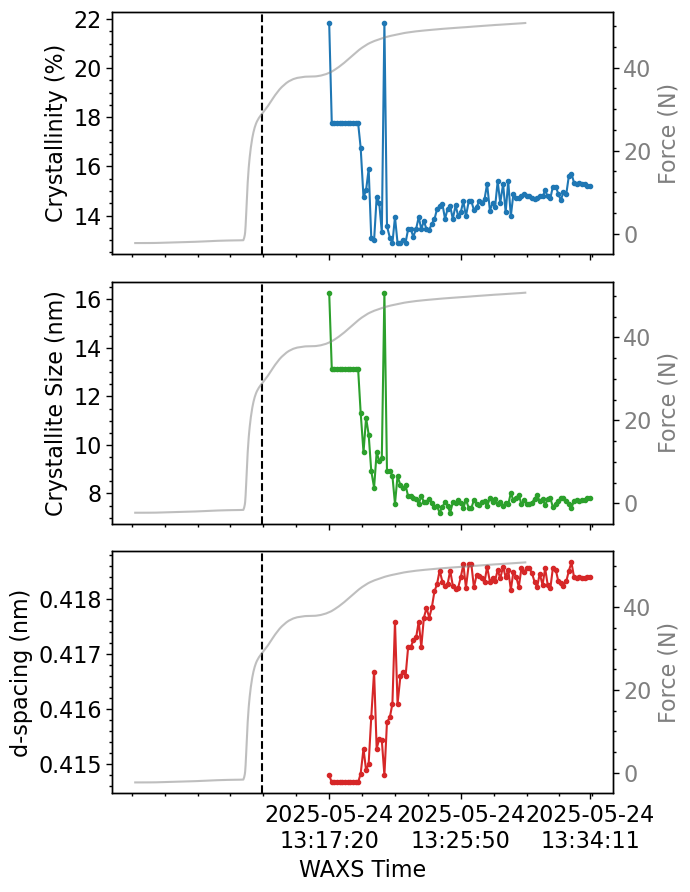

In [18]:
plot_waxs_with_tensile_overlay(
    folder_path_waxs=folder_path_waxs,
    filename_waxs="crystallinity_subtracted_Run5_LDPE_50C_50ums_scan003_azimuthal_data.xlsx",
    file_path_tensile=file_path_tensile,
    filename_tensile='Run5_LDPE_50C_50ums 24-05-25 13-30-01-20Exported.xlsx',
    vertical_line_time_str="2025-05-24 13:13:00"
)





